In [1]:
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import numpy as np
from jaxtyping import Array, Float
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from typing import Callable, Optional, Literal

jax.config.update("jax_enable_x64", True)

In [2]:
class Flow(eqx.Module):
    net: eqx.nn.MLP

    def __init__(
        self, dim: int = 2, h: int = 64, key: jax.random.PRNGKey = jax.random.PRNGKey(0)
    ):
        super().__init__()
        self.net = eqx.nn.MLP(
            in_size=dim + 1,
            out_size=dim,
            width_size=h,
            depth=3,
            activation=jax.nn.elu,
            key=key,
        )

    def __call__(self, t: Float, x_t: Array) -> Array:
        return self.net(jnp.concatenate([jnp.array([t]), x_t], axis=-1))

    def step(self, x_t: Array, t_start: Float, t_end: Float) -> Array:
        return x_t + (t_end - t_start) * self(
            t=t_start + (t_end - t_start) / 2,
            x_t=x_t + self(x_t=x_t, t=t_start) * (t_end - t_start) / 2,
        )

# Training

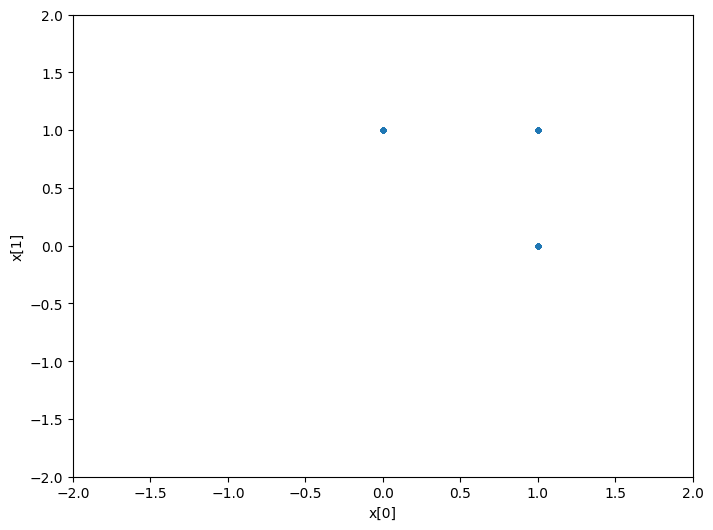

In [69]:
def make_binary(n_samples: int):
    samples = np.random.randint(0, 2, (n_samples, 2)).astype(np.float64)
    return samples


def make_logic(
    n_samples: int,
    logic_fn: Callable,
    n_aux: int = 0,
    noise: float = 0.0,
):
    # Make array with (n_samples, 2) shape
    # Each row is randomly chosen from tuples that satisfy the logic function
    # Auxiliary dimensions are filled with random binary values
    choices = []
    for x, y in [(0, 0), (0, 1), (1, 0), (1, 1)]:
        if logic_fn(x, y):
            choices.append((x, y))
    samples = np.random.choice(len(choices), n_samples)
    samples = np.array([choices[i] for i in samples]).astype(np.float64)
    if n_aux > 0:
        aux = np.random.randint(0, 2, (n_samples, n_aux)).astype(np.float64)
        samples = np.concatenate([samples, aux], axis=1)
    if noise > 0.0:
        samples += np.random.normal(0, noise, samples.shape)
    return samples


def make_xor(n_samples: int, n_aux: int = 0, noise: float = 0.0):
    return make_logic(n_samples, lambda x, y: x ^ y, n_aux, noise)


def make_or(n_samples: int, n_aux: int = 0, noise: float = 0.0):
    return make_logic(n_samples, lambda x, y: x | y, n_aux, noise)


def x_axis_mse_loss(pred: Array, target: Array) -> Array:
    # Onlye compute the MSE loss for the first dimension
    return jnp.mean((pred[:, 0] - target[:, 0]) ** 2)


# Plot make_or samples
samples = make_or(1000)
plt.figure(figsize=(8, 6))
plt.scatter(samples[:, 0], samples[:, 1], s=10)
plt.xlabel("x[0]")
plt.ylabel("x[1]")
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.show()

In [57]:
def loss(flow: Flow, t: Array, x_t: Array, dx_t: Array) -> Array:
    pred = jax.vmap(flow, in_axes=(0, 0))(t, x_t)
    l2 = optax.l2_loss(pred, dx_t)
    return l2.mean(), l2


def sample_data(
    dataset_fn: Callable,
    n_samples: int = 256,
    x_sample_fn: Callable = lambda shape: np.random.randn(*shape),
    t_sample_fn: Callable = lambda n: np.random.rand(n, 1),
) -> tuple[Array, Array, Array]:
    x_1 = jnp.array(dataset_fn(n_samples))
    x_0 = jnp.array(x_sample_fn(x_1.shape))
    t = jnp.array(t_sample_fn(len(x_1)))

    x_t = (1 - t) * x_0 + t * x_1
    dx_t = x_1 - x_0

    return t.squeeze(), x_t, dx_t


def uniform_phase_sample(shape):
    return np.random.uniform(-0.5, 1.5, shape)


def train(
    flow: Flow,
    loss: Callable,
    dataset_fn: Callable,
    batch_size: int = 256,
    lr: float = 1e-3,
    n_iters: int = 10000,
    print_every: int = 1000,
    x_sample_fn: Callable = lambda shape: np.random.randn(*shape),
    t_sample_fn: Callable = lambda n: np.random.rand(n, 1),
):

    @eqx.filter_jit
    def step(
        flow: Flow, opt_state: optax.OptState, t: Array, x_t: Array, dx_t: Array
    ) -> Array:
        (loss_mean, _), grads = eqx.filter_value_and_grad(loss, has_aux=True)(
            flow, t, x_t, dx_t
        )
        updates, opt_state = optimizer.update(grads, opt_state)
        flow = eqx.apply_updates(flow, updates)
        return flow, opt_state, loss_mean

    optimizer = optax.adam(lr)
    opt_state = optimizer.init(eqx.filter(flow, eqx.is_array))

    for iter in range(n_iters):
        t, x_t, dx_t = sample_data(
            dataset_fn,
            n_samples=batch_size,
            x_sample_fn=x_sample_fn,
            t_sample_fn=t_sample_fn,
        )

        flow, opt_state, loss_mean = step(flow, opt_state, t, x_t, dx_t)

        if iter % print_every == 0:
            print(f"Iter {iter}, Loss: {loss_mean}")
    return flow

# Sampling

In [51]:
def plot_flow(
    flow: Flow,
    n_dim: int = 2,
    sample_method: Literal["normal", "uniform"] = "normal",
    n_steps: int = 20,
    plot_every: int = 5,
):
    if sample_method == "normal":
        x = np.random.randn(300, n_dim)
    elif sample_method == "uniform":
        x = np.random.uniform(-0.5, 1.5, (300, n_dim))
    n_plot = n_steps // plot_every + 1

    fig, axes = plt.subplots(1, n_plot, figsize=(30, 4), sharex=True, sharey=True)
    time_steps = np.linspace(0, 1.0, n_steps + 1)

    axes[0].scatter(x[:, 0], x[:, 1], s=10)
    axes[0].set_title(f"t = {time_steps[0]:.2f}")
    axes[0].set_xlim(-2, 2)
    axes[0].set_ylim(-2, 2)

    for i in range(n_steps):
        x = jax.vmap(flow.step, in_axes=(0, None, None))(
            x, time_steps[i], time_steps[i + 1]
        )
        if (i + 1) % plot_every == 0:
            ax_idx = (i + 1) // plot_every
            axes[ax_idx].scatter(x[:, 0], x[:, 1], s=10)
            axes[ax_idx].set_title(f"t = {time_steps[i + 1]:.2f}")

    plt.tight_layout()
    plt.show()

    # Quantize the final states to integer pairs modular 2 and count occurrences
    # Plot the histogram of final states
    plt.figure(figsize=(8, 6))
    final_states = np.round(x).astype(int) % 2
    unique, counts = np.unique(final_states, axis=0, return_counts=True)
    plt.bar(range(len(unique)), counts)
    plt.xticks(range(len(unique)), [f"({u[0]},{u[1]})" for u in unique])
    plt.xlabel("Final State")
    plt.ylabel("Count")
    plt.show()

    if n_dim > 2:
        print("Cannot plot flow for dimensions greater than 2.")
        return

    fig, axes = plt.subplots(1, n_plot, figsize=(30, 4), sharex=True, sharey=True)
    time_steps = np.linspace(0, 1.0, n_steps + 1)

    grid = np.meshgrid(
        np.linspace(-2.0, 2.0, 30),
        np.linspace(-2.0, 2.0, 30),
    )
    grid = np.stack(grid, axis=-1).reshape(-1, 2)

    for i in range(n_steps + 1):
        if i % plot_every == 0:
            ax_idx = i // plot_every
            t = time_steps[i].repeat(grid.shape[0], axis=0)
            flow_output = jax.vmap(flow, in_axes=(0, 0))(t, grid)
            axes[ax_idx].quiver(
                grid[:, 0], grid[:, 1], flow_output[:, 0], flow_output[:, 1]
            )
            axes[ax_idx].set_title(f"t = {time_steps[i]:.2f}")
    plt.tight_layout()
    plt.show()

# Analyze loss

In [ ]:
# Plot loss vs time
def loss_vs_time(
    flow: Flow,
    loss: Callable,
    sampled_data: tuple[Array, Array, Array],
    window_size: int = 64,
):
    t, x_t, dx_t = sampled_data
    _, loss_values = loss(flow, t, x_t, dx_t)

    # Sort loss values by time
    sorted_indices = np.argsort(t)
    sorted_t = t[sorted_indices]
    sorted_loss = loss_values[sorted_indices]
    # Smooth loss values using a moving average
    smoothed_loss_x = np.convolve(
        sorted_loss[:, 0], np.ones(window_size) / window_size, mode="same"
    )
    smoothed_loss_y = np.convolve(
        sorted_loss[:, 1], np.ones(window_size) / window_size, mode="same"
    )
    plt.figure(figsize=(10, 5))
    # loss has two dimensions, we label them as x and y
    plt.plot(sorted_t, smoothed_loss_x, label="x")
    plt.plot(sorted_t, smoothed_loss_y, label="y")
    plt.legend()
    plt.xlabel("Time (t)")
    plt.ylabel("L2 Loss")
    plt.grid()
    plt.show()

Iter 0, Loss: 0.2953543433084184
Iter 1000, Loss: 0.16062681818729174
Iter 2000, Loss: 0.13690491845765965
Iter 3000, Loss: 0.11613875258194628
Iter 4000, Loss: 0.11997665075560554
Iter 5000, Loss: 0.11584404550909867
Iter 6000, Loss: 0.11601144132921191
Iter 7000, Loss: 0.12309442575759771
Iter 8000, Loss: 0.10030015110246794
Iter 9000, Loss: 0.12383382332568485


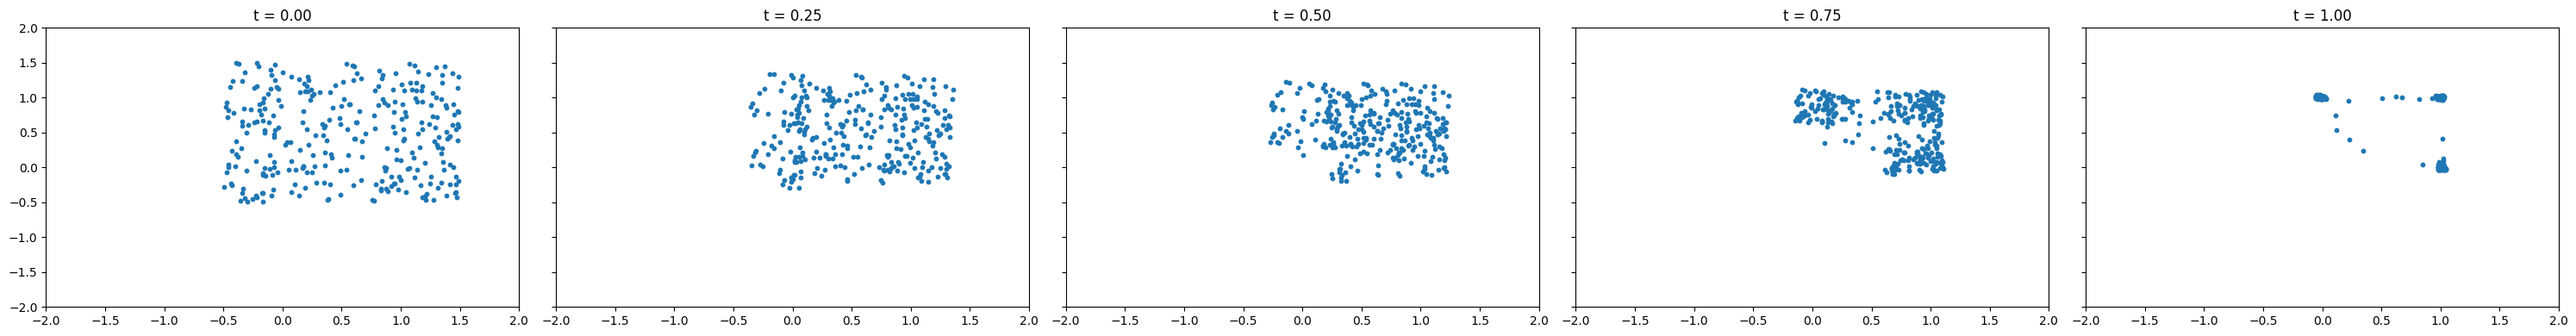

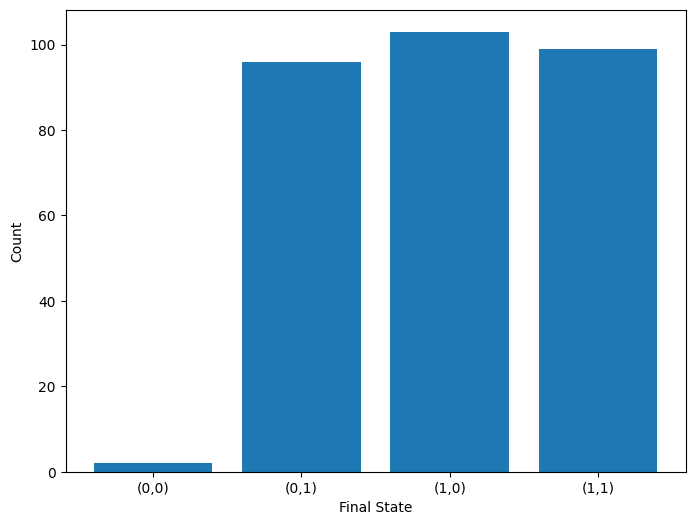

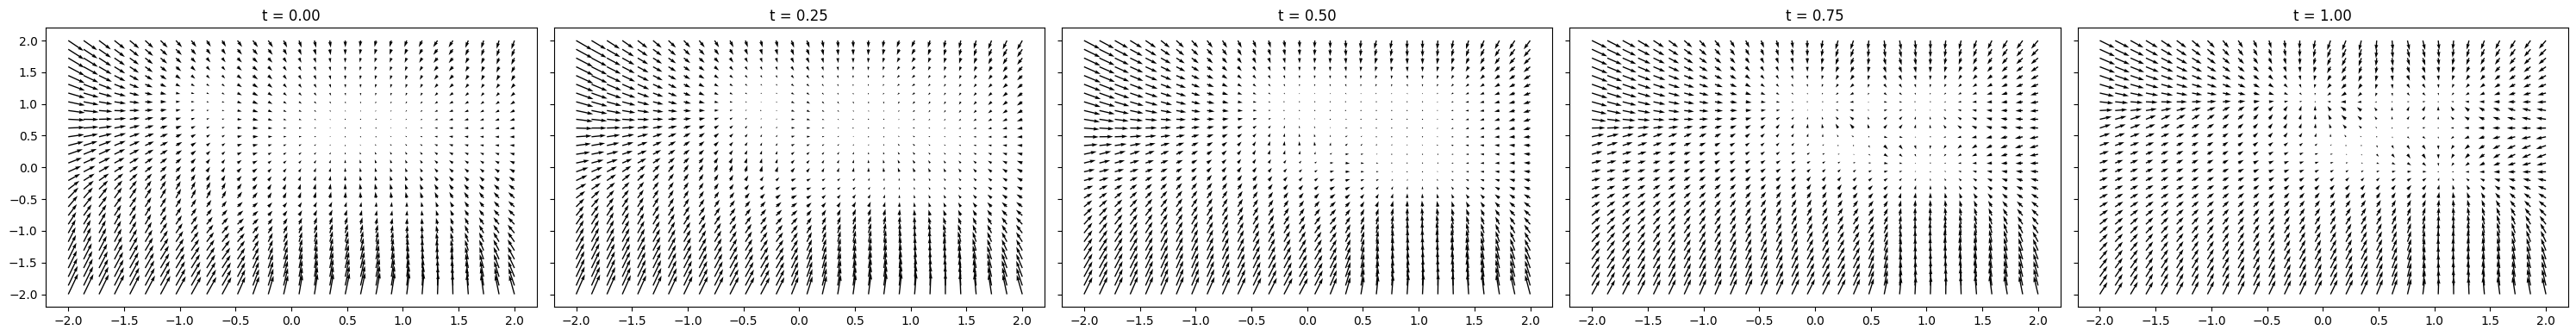

In [36]:
flow = train(
    flow=Flow(dim=2), loss=loss, dataset_fn=make_or, x_sample_fn=uniform_phase_sample
)
plot_flow(flow, sample_method="uniform")

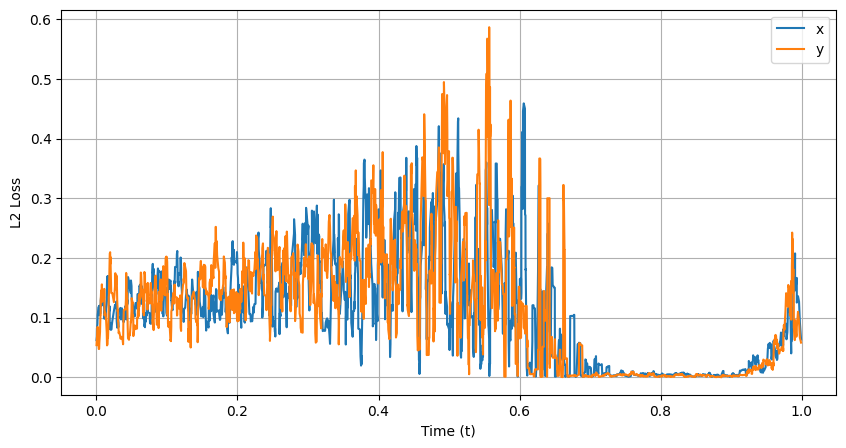

In [37]:
sampled_data = sample_data(
    dataset_fn=make_or,
    n_samples=2048,
    x_sample_fn=uniform_phase_sample,
    t_sample_fn=lambda n: np.random.rand(n, 1),
)
loss_vs_time(flow, loss, sampled_data, window_size=8)

# Oscillator Network

In [38]:
class OscFlow(Flow):
    coupling_matrix: Array
    locking_weight: Array
    use_time_weights: bool

    def __init__(
        self,
        dim: int,
        h: int = 64,
        key: jax.random.PRNGKey = jax.random.PRNGKey(0),
        use_time_weights: bool = True,
        coupling_matrix: Optional[Array] = None,
        locking_weight: Optional[Array] = None,
    ):
        cpl_key, lock_key, net_key = jax.random.split(key, num=3)
        self.coupling_matrix = (
            jax.random.normal(cpl_key, (dim, dim + 2))
            if coupling_matrix is None
            else coupling_matrix
        )
        self.locking_weight = (
            jax.random.normal(lock_key, (dim))
            if locking_weight is None
            else locking_weight
        )
        self.net = eqx.nn.MLP(
            in_size=1,
            out_size=dim * (dim + 3),
            width_size=h,
            depth=2,
            activation=jax.nn.elu,
            key=net_key,
        )
        self.use_time_weights = use_time_weights

    def __call__(self, t: Float, x_t: Array) -> Array:
        dim = x_t.shape[-1]
        bias_phase = jnp.array([0.0, 1.0])
        phase = jnp.concatenate([x_t, bias_phase], axis=-1)
        phase_diff = (phase[:, None] - phase[None, :])[:-2, :]
        coupling = jnp.sin(jnp.pi * phase_diff) * self.coupling_matrix
        locking = self.locking_weight * jnp.sin(2 * jnp.pi * x_t)

        if self.use_time_weights:
            time_weight = self.net(jnp.array([t]))
            coupling_time_weight = time_weight[: dim * (dim + 2)].reshape(dim, dim + 2)
            locking_time_weight = time_weight[dim * (dim + 2) :]

            coupling = coupling * coupling_time_weight
            locking = locking * locking_time_weight
        return coupling.sum(axis=1) - locking

Test flow with a known solution

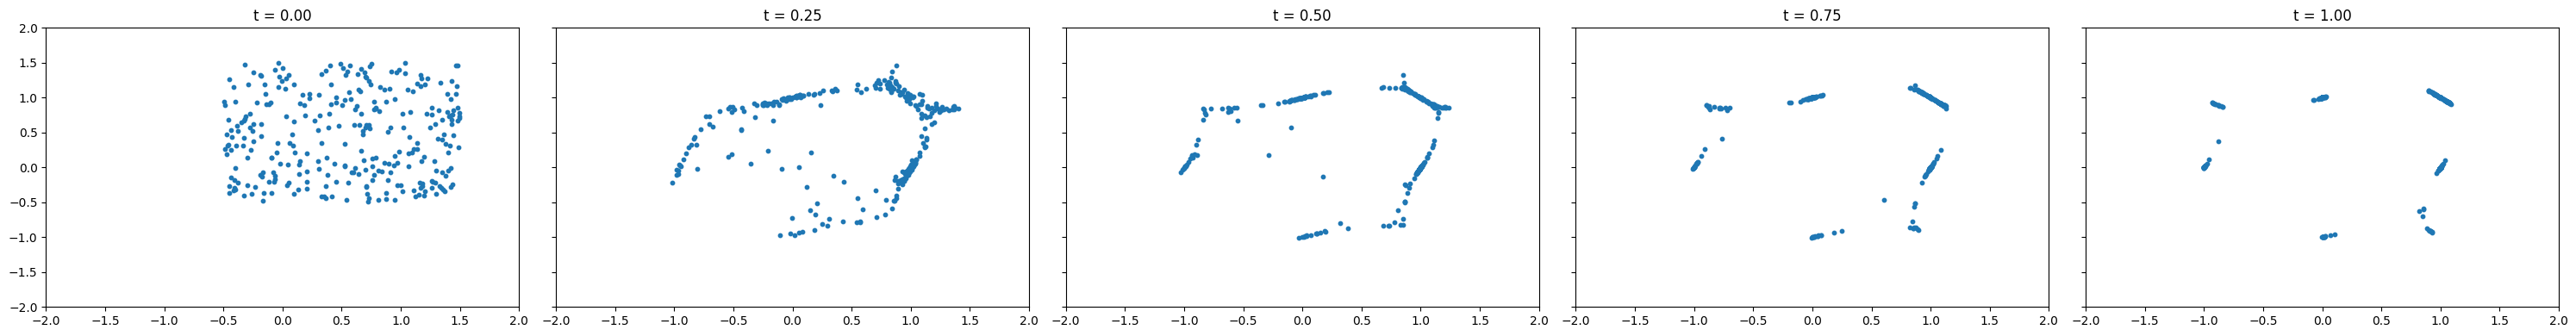

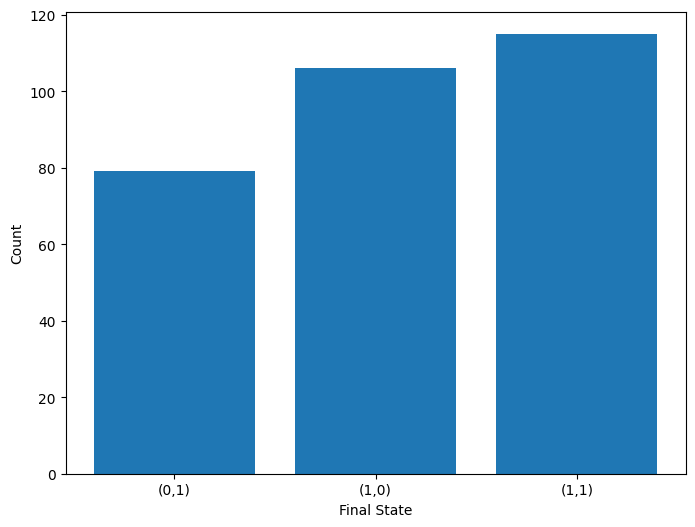

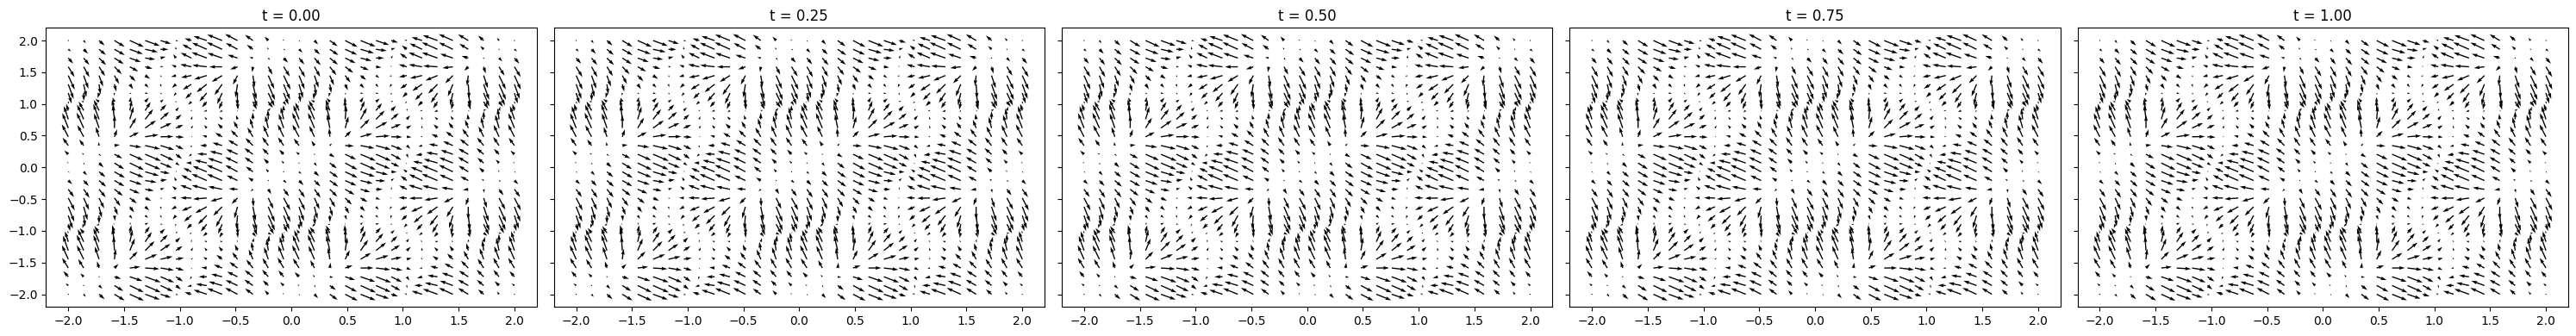

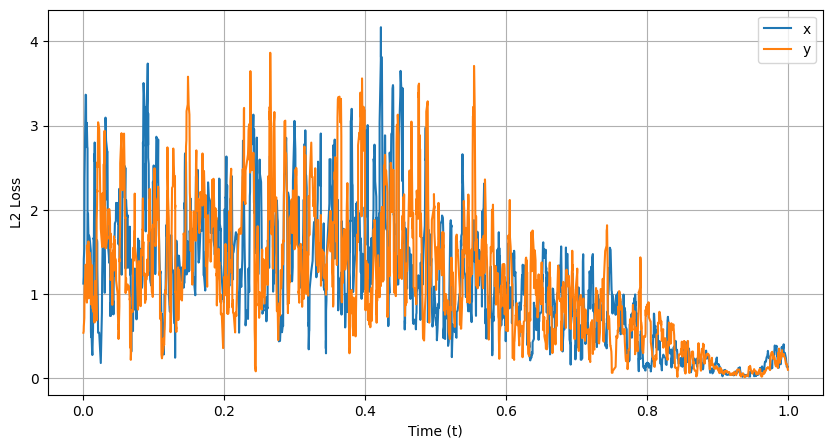

Iter 0, Loss: 1.1111928532916708


In [39]:
cpl_mat = jnp.array([[0.0, 1.5, 0.0, -1.5], [1.5, 0.0, 0.0, -1.5]])

flow = OscFlow(
    dim=2,
    coupling_matrix=cpl_mat,
    locking_weight=jnp.array([1.0, 1.0]),
    use_time_weights=False,
)
plot_flow(flow, sample_method="uniform")
loss_vs_time(
    flow,
    loss,
    sampled_data,
    window_size=8,
)
_ = train(
    flow=flow,
    loss=loss,
    dataset_fn=make_or,
    n_iters=1,
    print_every=1,
    x_sample_fn=uniform_phase_sample,
)

Iter 0, Loss: 0.31596227703132623
Iter 1000, Loss: 0.1809956746891356
Iter 2000, Loss: 0.1732964472119777
Iter 3000, Loss: 0.18804683218099705
Iter 4000, Loss: 0.2121179255884814
Iter 5000, Loss: 0.19365485841852165
Iter 6000, Loss: 0.1821491234944512
Iter 7000, Loss: 0.15919347644035547
Iter 8000, Loss: 0.18136920959979674
Iter 9000, Loss: 0.18148014403368273


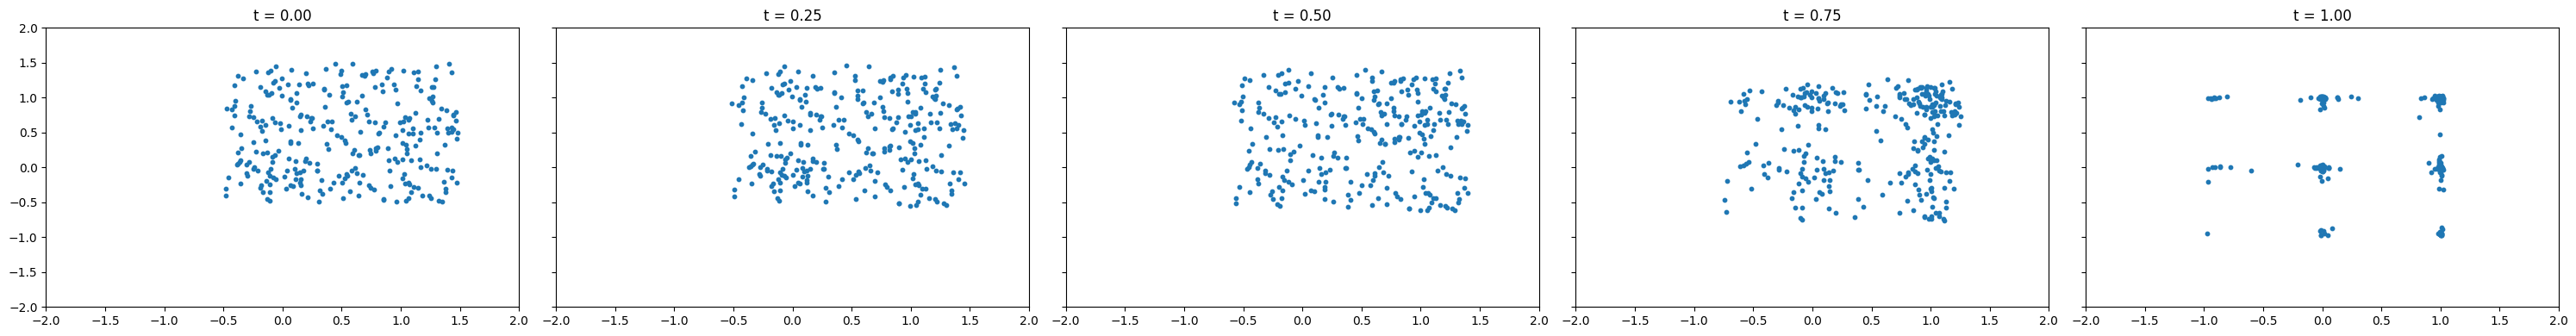

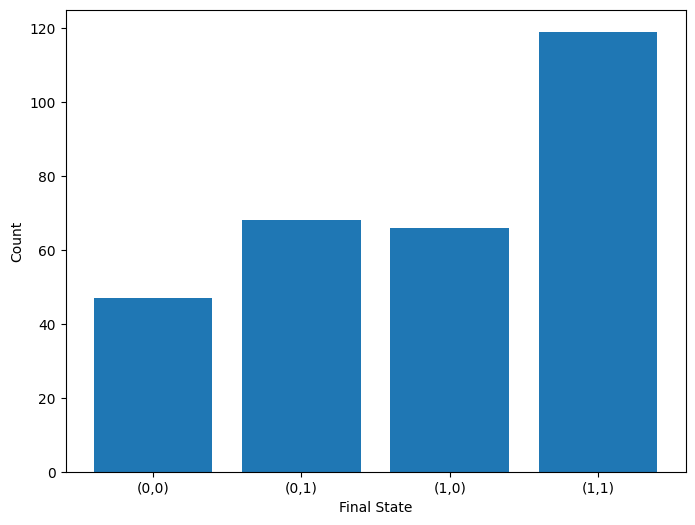

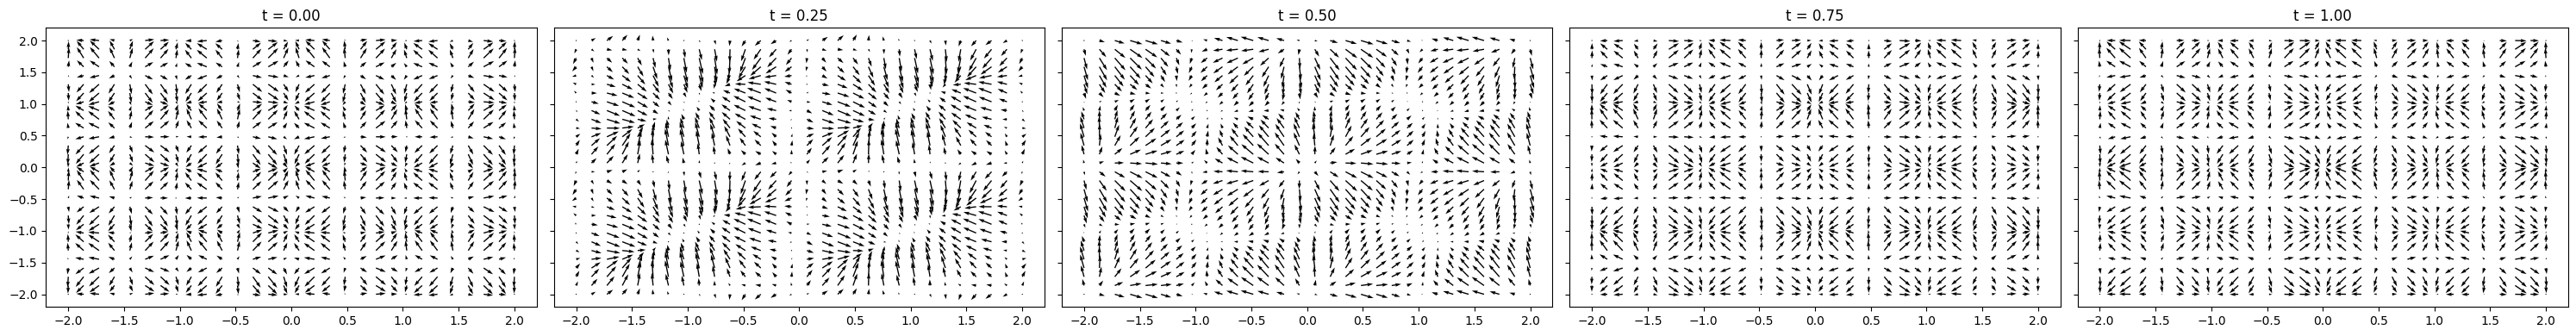

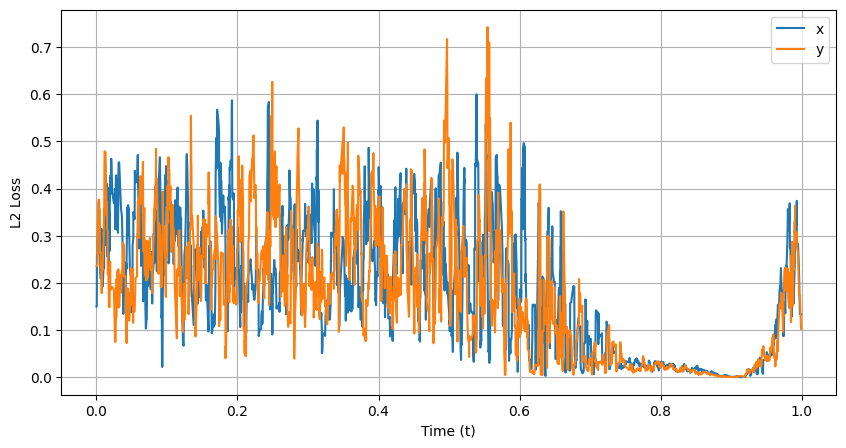

In [40]:
flow = train(
    flow=OscFlow(
        dim=2,
    ),
    loss=loss,
    dataset_fn=lambda n_samples: make_or(n_samples),
    x_sample_fn=uniform_phase_sample,
)
plot_flow(flow, sample_method="uniform")
loss_vs_time(
    flow,
    loss,
    sampled_data,
    window_size=8,
)

Iter 0, Loss: 0.36282007825704926
Iter 1000, Loss: 0.26817608126571
Iter 2000, Loss: 0.28833519811308617
Iter 3000, Loss: 0.2604830989244249
Iter 4000, Loss: 0.27747249394444773
Iter 5000, Loss: 0.2641373251559742
Iter 6000, Loss: 0.24334465758649224
Iter 7000, Loss: 0.2769006648074713
Iter 8000, Loss: 0.27361288283096274
Iter 9000, Loss: 0.2698886710875197


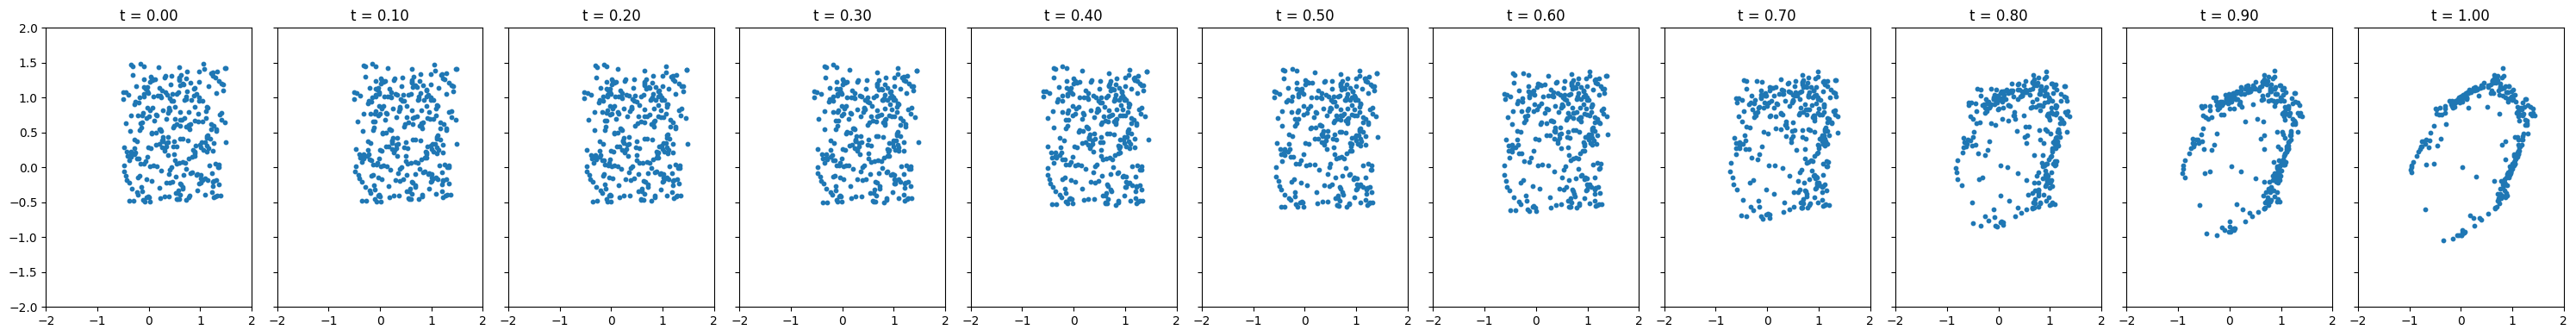

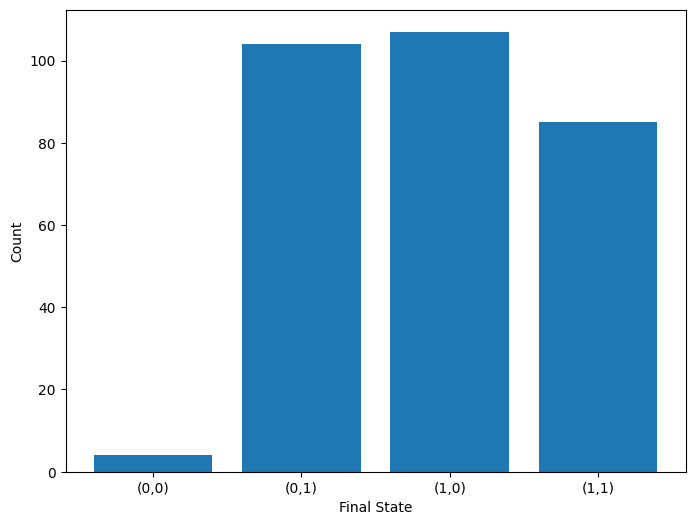

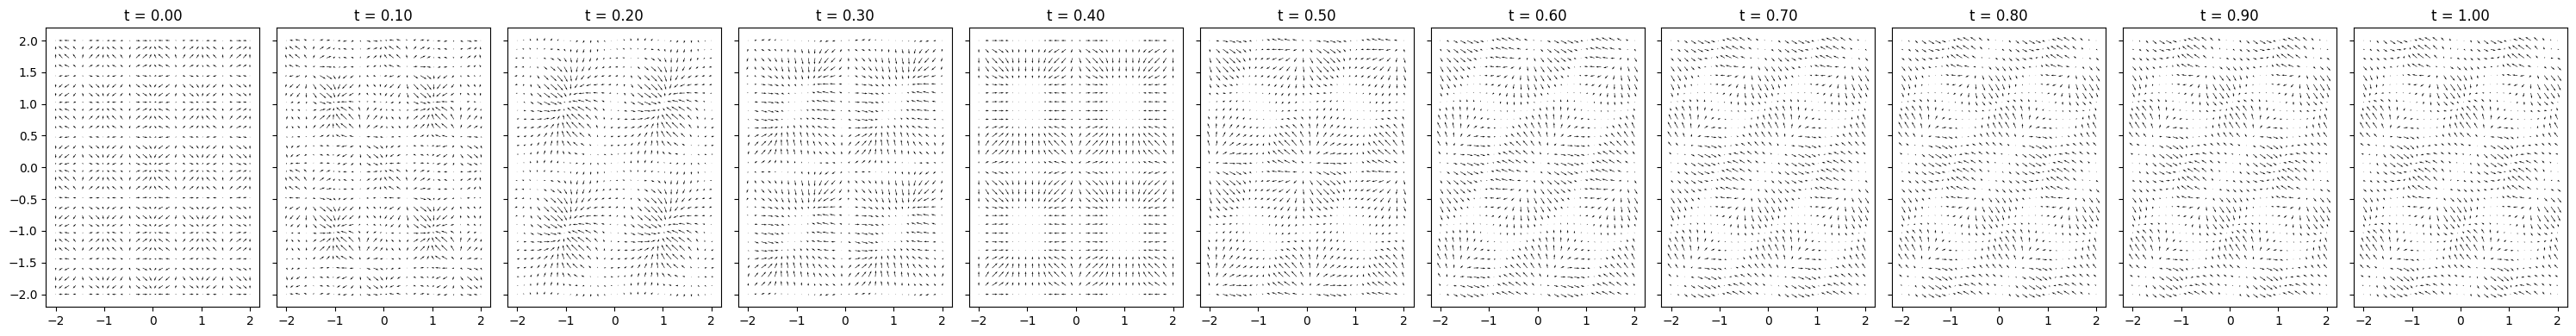

[0.52853052 0.70225525 0.85943213 ... 0.94538651 0.36588258 0.639015  ]


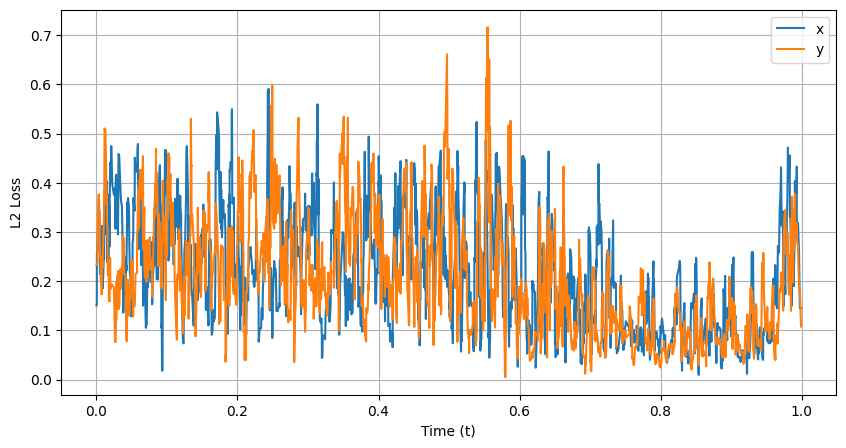

In [52]:
flow = train(
    flow=OscFlow(
        dim=2,
    ),
    loss=loss,
    dataset_fn=lambda n_samples: make_or(n_samples),
    x_sample_fn=uniform_phase_sample,
    t_sample_fn=lambda n: np.random.rand(n, 1) / 2,
)
plot_flow(flow, sample_method="uniform", plot_every=2)
loss_vs_time(
    flow,
    loss,
    sampled_data,
    window_size=8,
)

Iter 0, Loss: 0.30838266104333645
Iter 1000, Loss: 0.08479064734785421
Iter 2000, Loss: 0.10184505807257034
Iter 3000, Loss: 0.08356279913652388
Iter 4000, Loss: 0.10060726917650559
Iter 5000, Loss: 0.08057647992945671
Iter 6000, Loss: 0.09891760748737743
Iter 7000, Loss: 0.07571937999550181
Iter 8000, Loss: 0.08733255437371139
Iter 9000, Loss: 0.07897723313921486


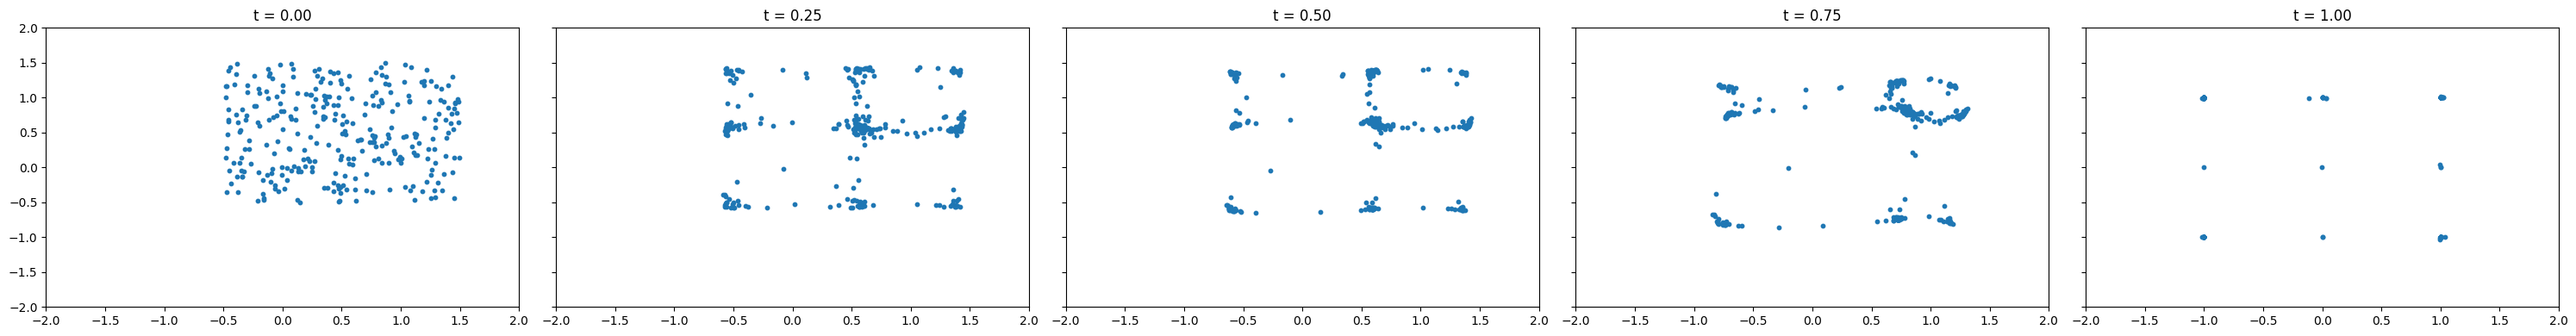

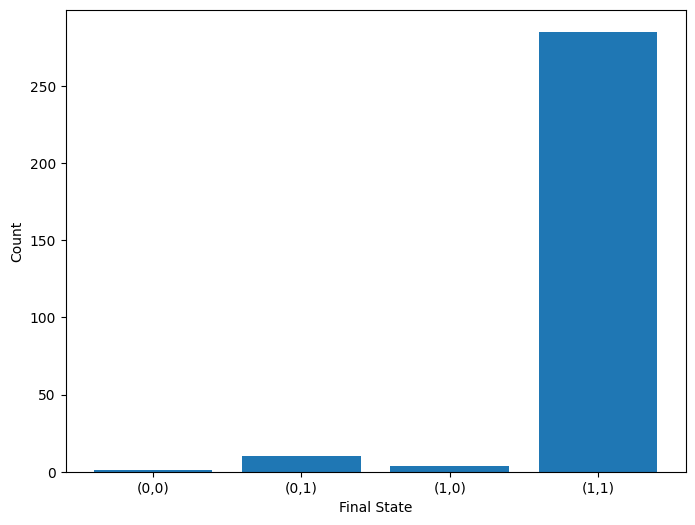

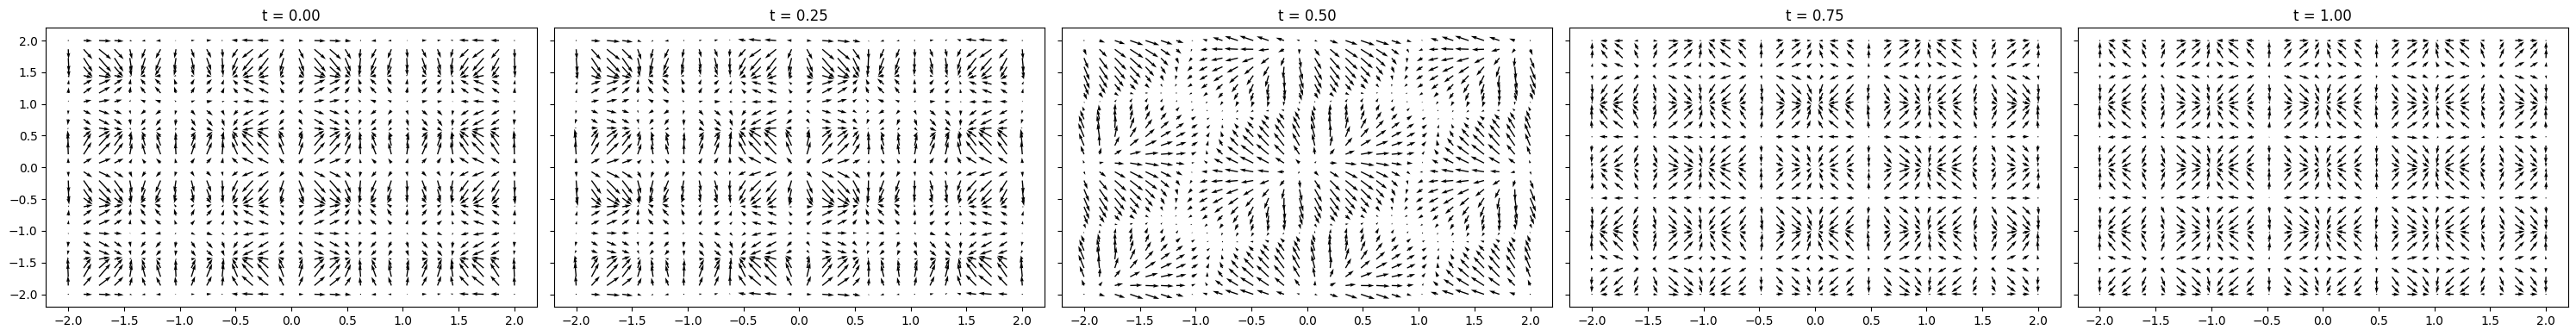

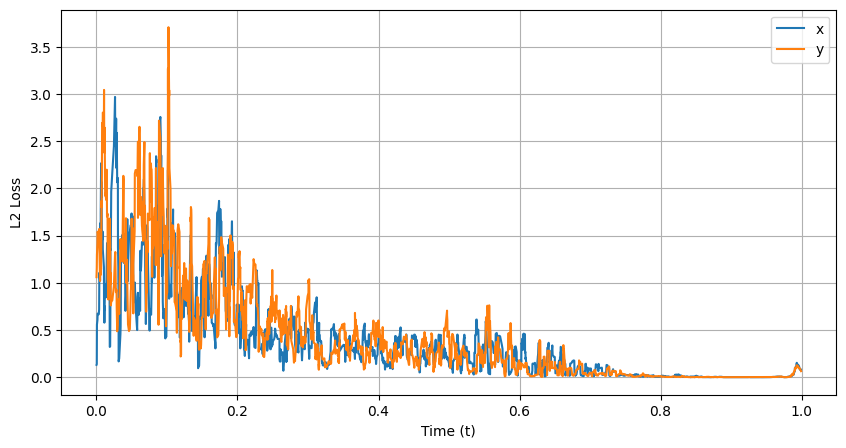

In [ ]:
flow = train(
    flow=OscFlow(
        dim=2,
    ),
    loss=loss,
    dataset_fn=lambda n_samples: make_or(n_samples),
    x_sample_fn=uniform_phase_sample,
    t_sample_fn=lambda n: np.random.rand(n, 1) / 2 + 0.5,
)
plot_flow(flow, sample_method="uniform")
loss_vs_time(
    flow,
    loss,
    sampled_data,
    window_size=8,
)

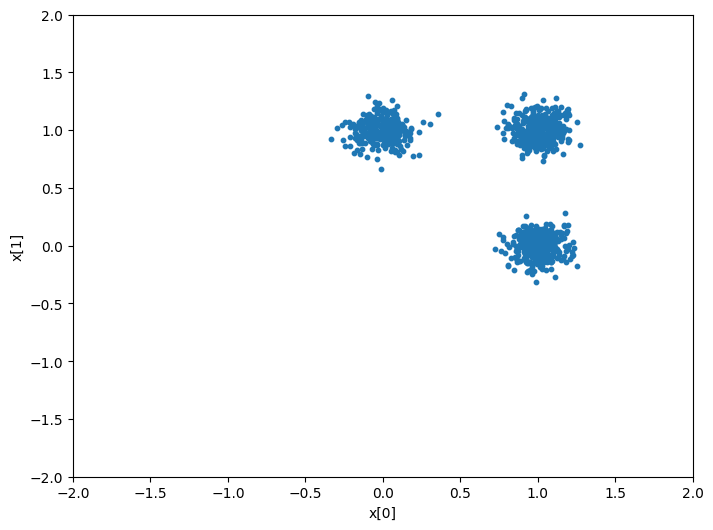

Iter 0, Loss: 0.31752567090180256
Iter 1000, Loss: 0.2182159746302273
Iter 2000, Loss: 0.24159666153158055
Iter 3000, Loss: 0.22005673662305758
Iter 4000, Loss: 0.22757163858758567
Iter 5000, Loss: 0.2227704054237606
Iter 6000, Loss: 0.2264893168226355
Iter 7000, Loss: 0.2421818623380538
Iter 8000, Loss: 0.21698159869091532
Iter 9000, Loss: 0.21902387319091024


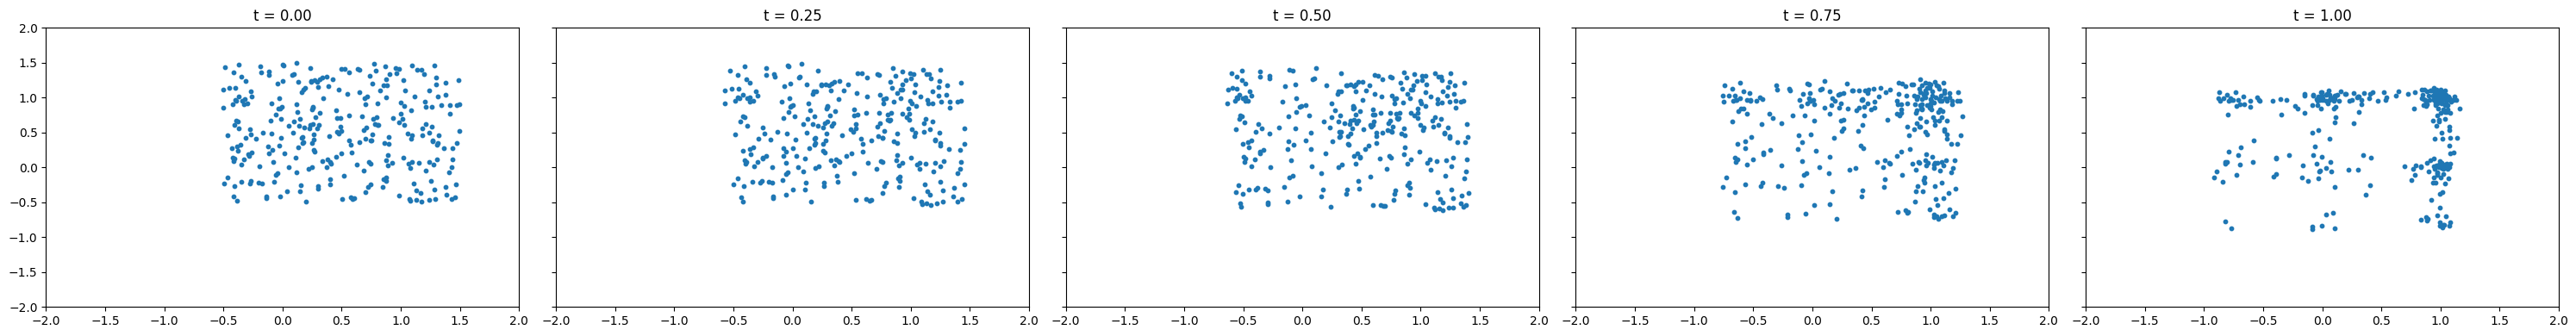

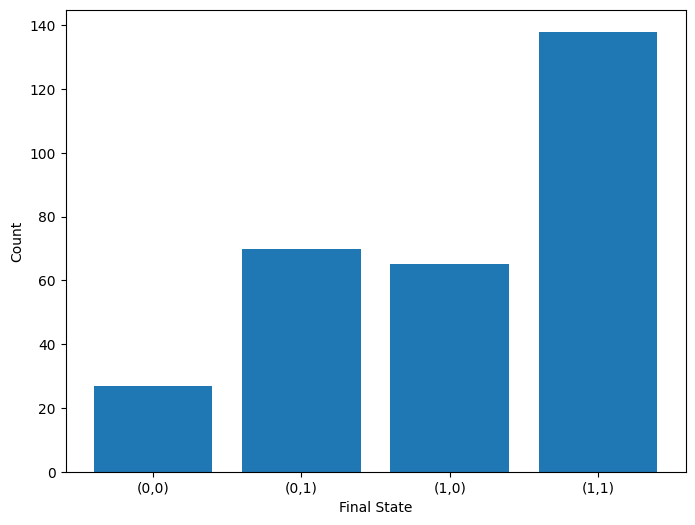

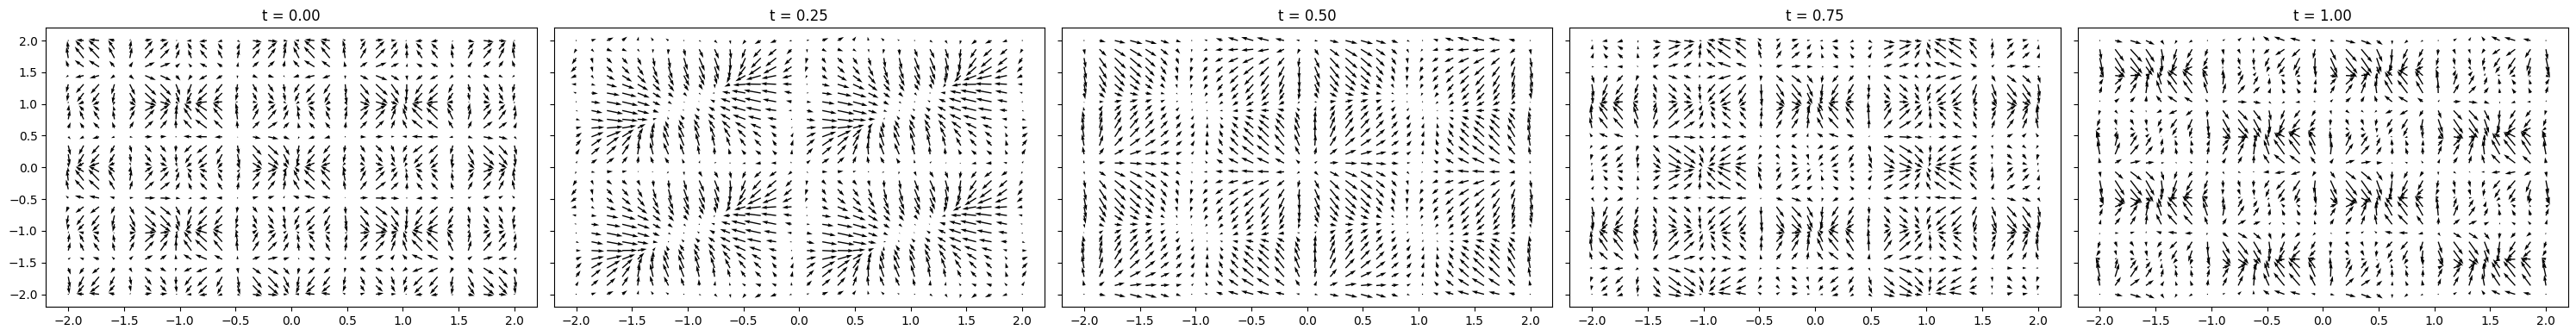

[0.94591506 0.11024648 0.042469   ... 0.44845638 0.86255426 0.47231331]


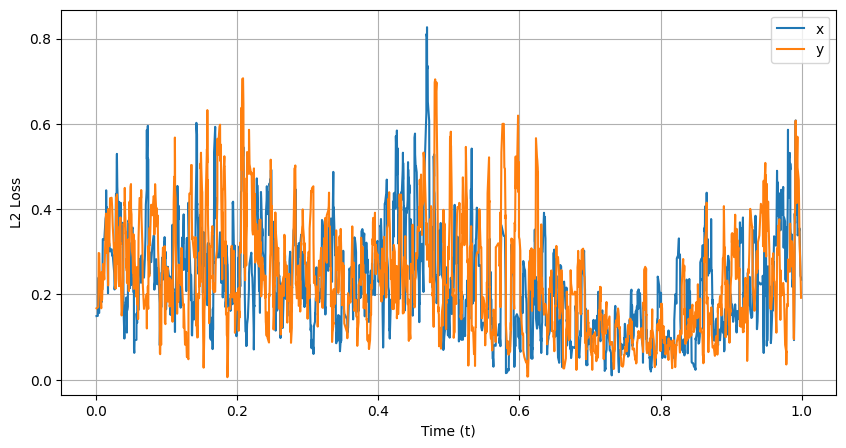

In [70]:
noise_std = 0.1

desired_samples = make_or(1000, noise=noise_std)
# Plot noisy_sampled_data
plt.figure(figsize=(8, 6))
plt.scatter(desired_samples[:, 0], desired_samples[:, 1], s=10)
plt.xlabel("x[0]")
plt.ylabel("x[1]")
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.show()
flow = train(
    flow=OscFlow(
        dim=2,
    ),
    loss=loss,
    dataset_fn=lambda n_samples: make_or(n_samples, noise=noise_std),
    x_sample_fn=uniform_phase_sample,
    t_sample_fn=lambda n: np.random.rand(n, 1),
)

plot_flow(flow, sample_method="uniform")

noisy_sampled_data = sample_data(
    dataset_fn=lambda n_samples: make_or(n_samples, noise=noise_std),
    n_samples=2048,
    x_sample_fn=uniform_phase_sample,
    t_sample_fn=lambda n: np.random.rand(n, 1),
)
loss_vs_time(
    flow,
    loss,
    noisy_sampled_data,
    window_size=8,
)

## Issues on the path
- The target distribution is periodic, should the flow become on a sphere instead of euclidean space?
- Beginning of the path is more difficult to learn than the final path close to attractors (general MLP has this issue too and learns the average of attractors). 
- Time-varying couling weight shoud not be a complicated function.
